# Maxar Open Data Processing and Flood Analysis Pipeline

The code below loads Maxar's satellite imagery data, processes it for a specific region of interest and then generates a flood mask. It utilizes pystac-client for searching and accessing data, odc-stac for loading STAC assets and representing geospatial data, XArray and geopandas for manipulating data and finally Dask for performing parallel, distributed computing.

### Environment Setup

We import all required libraries and configure logger. Paths for outputs and other useful directories are also defined afterwards. As we are using relative paths, we change our working directory to the root folder.

In [1]:
# Imports
import os
import dask
import boto3
import logging
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import pystac
import rasterio
import rioxarray
import dask.array as da
import numexpr as ne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from copy import deepcopy
from datetime import datetime
from typing import List, Dict
from pystac_client import Client as pystac_client
from distributed import wait
from shapely.geometry import shape
from rasterio.features import shapes
from odc.stac import configure_rio, stac_load
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles

In [2]:
# Set up logger
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("maxar_pipeline")

# Suppress noisy third-party warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="odc")

# Suppress thirdparty library logs/noise 
logging.getLogger("botocore.credentials").setLevel(logging.WARNING)
logging.getLogger("rasterio._env").setLevel(logging.ERROR)
logging.getLogger("distributed").setLevel(logging.ERROR)
logging.getLogger("distributed.http.proxy").setLevel(logging.ERROR)
logging.getLogger("distributed.scheduler").setLevel(logging.ERROR)
logging.getLogger("distributed.nanny").setLevel(logging.ERROR)
logging.getLogger("distributed.core").setLevel(logging.ERROR)
logging.getLogger("distributed.diskutils").setLevel(logging.ERROR)

##### GDAL Environment Configuration

When loading satellite imagery from remote cloud storage (such as Maxar tiles hosted on S3 or HTTPS), GDAL needs to fetch image data over the network one chunk at a time. By default, GDAL is conservative in how it does this, which can result in slow reads, unnecessary network requests, and failed chunk loads under poor connectivity.

The settings below tune GDAL's network and memory behaviour before any data is loaded. Think of it as configuring a GIS application's performance settings before opening a large raster except here we are doing it programmatically so that every read operation in this notebook benefits automatically. These values are set once at the top of the notebook and apply globally to all subsequent `stac_load` and `rasterio` operations.

In [3]:
GDAL_ENV = {
    # Combine multiple small adjacent read requests into a single larger one
    "GDAL_HTTP_MERGE_CONSECUTIVE_REQUESTS": "YES",
    # Allows multiple requests to share one connection
    "GDAL_HTTP_MULTIPLEX": "YES",
    # Number of times GDAL will retry a failed HTTP request before giving up
    "GDAL_HTTP_MAX_RETRY": 3,
    # Seconds to wait between retry attempts
    "GDAL_HTTP_RETRY_DELAY": 0.5,
    # GDAL issues unnecessary listing requests which slows down processing
    "GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR",
    # Restrict GDAL's virtual filesystem driver
    "CPL_VSIL_CURL_ALLOWED_EXTENSIONS": ".tif,.tiff",
    # Size of the low-level HTTP byte-range cache in bytes
    "CPL_VSIL_CURL_CACHE_SIZE": 200 * 1024 * 1024,  # 200 MB
    # Maximum memory GDAL uses to cache decoded image blocks (tiles) in MB
    "GDAL_CACHEMAX": 512,  # MB
    # Enable GDAL's per-file read-ahead cache, works on top of the curl cache
    "VSI_CACHE": "TRUE",
    # Size of the per-file read-ahead cache in bytes
    "VSI_CACHE_SIZE": 100 * 1024 * 1024,  # 100 MB
}

# Set at process level (inherited by all dask worker threads)
for key, val in GDAL_ENV.items():
    os.environ[key] = str(val)  # os.environ requires strings

# Also open rasterio.Env for main thread rasterio calls
_env = rasterio.Env(**GDAL_ENV)
_env.__enter__()

In [4]:
from pathlib import Path

# Directories
root_dir = Path().resolve().parent
outputs_dir = root_dir / "outputs"

# Create if they don't exist
outputs_dir.mkdir(parents=True, exist_ok=True)

# Set working directory to root
os.chdir(root_dir)

logger.info(f"Working dir: {os.getcwd()}")

04:40:54 [INFO] maxar_pipeline — Working dir: C:\Users\muham\Projects\Shipped_Projects\EO_Processing


### Load Env Variables and Configurations

All user-configurable parameters are collected here. These can be sensitive information (e.g. AWS Credentials) or other configuration/setup variables that are either hardcoded or need to be defined once and used through out.

**This is the only section you need to edit** to run the pipeline on a different event or location.

#### Key Concepts

- **AOI (Area of Interest):** Defined here as a GeoJSON polygon in **EPSG:4326** (WGS84 decimal degrees). This is the standard coordinate system used by GeoJSON.
- **STAC Collection ID:** Each Maxar event contains one or more image collections, identified by a sensor catalog ID (e.g., `104001007D711B00`). Setting this to `None` searches across all collections in the event (useful for discovery).
- **Asset Key `ms_analytic`:** Maxar imagery is delivered in multiple formats. The `ms_analytic` asset is the **multispectral analytical product** containing calibrated reflectance values across 4 or 8 spectral bands. This is what we use for index calculations. The `visual` asset is a pre-processed RGB for display only with no NIR bands (or other helpful bands for indices).


In [5]:
# Credentials and other user-defined/environment variables
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env")
"""
Following environment variables have been defined and exposed

# AWS Credentials and paths for S3 access
AWS_ACCESS_KEY_ID=
AWS_SECRET_ACCESS_KEY=
AWS_BUCKET_NAME=
AWS_BUCKET_PATH=
# Define event and collection id of interest
CATALOG_URL=
EVENT_NAME=
COLLECTION_ID=
FLOOD_DATE=
# Maxar asset key for multispectral 8-band/4-band imagery
ASSET_KEY="ms_analytic" (can be visual, pan)
MAX_TILES=
"""
logger.info("Environment variables loaded successfully.")

04:40:54 [INFO] maxar_pipeline — Environment variables loaded successfully.


#### Area of Interest (AOI)
A geojson can be manually defined using online tools e.g. [geojson.io](https://geojson.io/).

In [6]:
# Define AOI to be used for fetching related tiles
aoi_geojson = {
    "type": "Polygon",
    "coordinates": [[[36.351706959328055,15.524946754752264], [36.34579368054551,15.492658243466522], [36.39478941902624,15.360738609358691],
                         [36.473914720825405,15.364539934446114], [36.41252925537287,15.407978724295234], [36.36691253333902,15.52657461316376],
                         [36.358183407518425,15.526303304320308], [36.351706959328055,15.524946754752264]]],
} # Kassala, Sudan

In [7]:
# Load user-defined geojson into a shapely object and find intersecting items
aoi_geom = shape(aoi_geojson)
aoi_bbox = list(aoi_geom.bounds)
logger.info(f"BBOX AOI - {aoi_bbox}")

04:40:54 [INFO] maxar_pipeline — BBOX AOI - [36.34579368054551, 15.360738609358691, 36.473914720825405, 15.52657461316376]


### Search for data (STAC Catalog)
Instead of manually downloading files, we use STAC (SpatioTemporal Asset Catalog). This allows us to search for imagery by event name and location. Note that maxar is a static STAC catalog and as such doesn't allow searching through client so we need to get items based on either collection_id (defined earlier) or by using a custom AOI intersection.

Here, we are targeting the 2022 Sudan Floods. We navigate the Maxar Open Data STAC catalog to find tiles that:
1. Belong to our chosen event
2. Spatially intersect our AOI
3. Contain the `ms_analytic` asset

We perform this **before downloading any pixels**. STAC metadata files are tiny JSON documents and this whole discovery step typically takes only a few seconds even for large events with hundreds of tiles.

**Why filter for the asset key?**  
Not every STAC item in an event has every asset type. Some tiles may only have a `visual` (RGB) preview but no analytical multispectral product. Filtering early prevents downstream errors.

In [8]:
# Collection id can be null so do a check
EVENT_NAME = None if os.getenv('EVENT_NAME') == 'None' else os.getenv('EVENT_NAME')
COLLECTION_ID = None if os.getenv('COLLECTION_ID') == 'None' else os.getenv('COLLECTION_ID')

MS_ASSET_KEY = os.getenv('ASSET_KEY')
FLOOD_DATE = os.getenv('FLOOD_DATE')
MAX_TILES = int(os.getenv('MAX_TILES'))

In [9]:
# Load catalog and collection all items from our event collection
# Be Cautious with COLLECTION_ID == None as large catalogs can take forever on this. Better to specify one in that case
catalog = pystac_client.open(os.getenv('CATALOG_URL'))
collection = catalog.get_child(EVENT_NAME).get_child(COLLECTION_ID) if COLLECTION_ID else catalog.get_child(EVENT_NAME)
items = list(collection.get_all_items())

logger.info(f"Found {len(items)} in {EVENT_NAME} event with collection id {COLLECTION_ID} collection")

04:41:33 [INFO] maxar_pipeline — Found 57 in Sudan-flooding-8-22-2022 event with collection id None collection


In [10]:
# Filter items based on whether they intersect our area of interest
items = [item for item in items if aoi_geom.intersects(shape(item.geometry))]
# Filter items based on whether they contain the asset key or not
matched_items = [item for item in items if MS_ASSET_KEY in item.assets.keys()
                ]
logger.info(f"Found {len(matched_items)} items intersecting AOI bounds and with asset_key - {MS_ASSET_KEY}")

04:41:33 [INFO] maxar_pipeline — Found 10 items intersecting AOI bounds and with asset_key - ms_analytic


In [11]:
# Quick check of available assets and bands in the imagery items
if matched_items:
    logger.info(f"Available assets: {list(matched_items[0].assets.keys())}")
    band_meta = matched_items[0].assets[MS_ASSET_KEY].extra_fields.get("eo:bands", [])
    
    logger.info(f"Bands in {MS_ASSET_KEY}: {[b['name'] for b in band_meta]}")

04:41:33 [INFO] maxar_pipeline — Available assets: ['data-mask', 'ms_analytic', 'pan_analytic', 'visual']
04:41:33 [INFO] maxar_pipeline — Bands in ms_analytic: ['BAND_C', 'BAND_B', 'BAND_G', 'BAND_Y', 'BAND_R', 'BAND_RE', 'BAND_N', 'BAND_N2']


#### Helper functions for pystac items

In [12]:
# Convert a list of STAC Items into a GeoDataFrame
def items_to_geodataframe(items: List[pystac.Item]):
    """
    Convert a list of pystac.Item objects to a GeoDataFrame. 
    Properties (epsg, datetime, cloud cover) are promoted to columns.
    """
    _items = []
    for i in items:
        props = i.properties        
        # Parse datetime
        dt_raw = props.get("datetime")
        try:
            dt = datetime.fromisoformat(dt_raw.replace("Z", "+00:00")) if dt_raw else None
        except (ValueError, AttributeError):
            dt = None
        _items.append({
            "item_id": i.id,
            "quadkey": props.get("quadkey"),
            "grid:code": props.get("grid:code"),
            "utm_zone": props.get("utm_zone"),
            "datetime": dt,
            "catalog_id": props.get("catalog_id"),
            "crs": props.get("proj:code"),
            "bbox": props.get("proj:bbox"),
            "platform": props.get("platform"),
            "gsd": props.get("gsd"),
            "area": props.get("tile:data_area"),
            "clouds_area": props.get("tile:clouds_area", 0.0),
            "clouds_percent": props.get("tile:clouds_percent", 0),
            "asset_keys": ",".join(i.assets.keys()),
            "geometry": shape(i.geometry) if i.geometry else None,
            "_item":       i,   # keep reference for later use with odc-stac
        })
    gdf = gpd.GeoDataFrame(_items, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.dropna(subset=["geometry"])
    if "datetime" in gdf.columns:
        gdf = gdf.sort_values("datetime").reset_index(drop=True)
    logger.info(f"GeoDataFrame created: {len(gdf)} rows, CRS={gdf.crs}")
    return gdf


def summarise_items(gdf: gpd.GeoDataFrame) -> None:
    """
    Print a formatted table of selected STAC items and plot their footprints.
    """
    logger.info(f"\n{'─'*80}")
    logger.info(f"  {'ID':<38} {'Date':<12} {'Cloud%':>7}  {'Platform':<12}  Assets")
    logger.info(f"{'─'*80}")
    for _, row in gdf.iterrows():
        date_str  = row["datetime"].strftime("%Y-%m-%d") if row["datetime"] else "N/A"
        cloud_str = f"{row['clouds_percent']:.1f}%" if isinstance(row["clouds_percent"], (int, float)) else "—"
        platform  = str(row["platform"] or "—")[:12]
        assets    = row["asset_keys"]
        logger.info(f"  {row['item_id']:<38} {date_str:<12} {cloud_str:>7}  {platform:<12}  {assets}")
    logger.info(f"{'─'*80}")
    logger.info(f"  Total: {len(gdf)} item(s)\n")

    # plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    # get total boundary of the gdf for AOI bounding box
    west, south, east, north = gdf.union_all().bounds
    gdf.plot(
        ax=ax, facecolor="steelblue", edgecolor="navy",
        alpha=0.35, linewidth=0.8,
    )
    # Draw AOI bounding box
    aoi_patch = mpatches.FancyArrowPatch
    aoi_rect = plt.Rectangle(
        (west, south), east - west, north - south,
        linewidth=2, edgecolor="crimson", facecolor="none",
        linestyle="--", label="AOI",
    )
    ax.add_patch(aoi_rect)
    ax.set_xlim(west - 0.25, east + 0.25)
    ax.set_ylim(south - 0.25, north + 0.25)
    ax.set_title(f"STAC Item Footprints ({len(gdf)} tiles)", fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def patch_maxar_item(item: pystac.Item) -> pystac.Item:
    """
    Patch maxar item to reflect odc-stac loading pipeline. 
    Bands in  maxar are nested inside the asset_key attributes whereas odc-stac expects sentinel type bands.
    """
    item_dict = deepcopy(item.to_dict())
    # Promote ms_analytic eo:bands to item properties for alias registration
    asset = item_dict["assets"][MS_ASSET_KEY]
    eo_bands = asset.get("eo:bands", [])
    
    if not eo_bands or not isinstance(eo_bands[0], dict):
        raise ValueError(f"Unexpected eo:bands format in item {item.id}: {eo_bands}")

    item_dict["properties"]["eo:bands"] = eo_bands
    # Patch raster:bands on ALL assets so the bands dict registration
    for asset_name, band_count in ASSET_BAND_COUNTS.items():
        if asset_name not in item_dict["assets"]:
            continue
        item_dict["assets"][asset_name]["raster:bands"] = [
            {
                "data_type": "uint16" if asset_name != "visual" else "uint8",
                "nodata": 0,
                "unit": "1",
            }
            for _ in range(band_count)
        ]

    return pystac.Item.from_dict(item_dict)

### Load Items to GeoDataframe and Display Extents

Initial data discovery and summary using geoDataframes. Load items into gdf and display information related to these items (e.g. columns, bounding boxes etc.).

In [13]:
items_gdf = items_to_geodataframe(matched_items)
logger.info(f"Total items in collection: {len(items_gdf)}")

04:41:33 [INFO] maxar_pipeline — GeoDataFrame created: 10 rows, CRS=EPSG:4326
04:41:33 [INFO] maxar_pipeline — Total items in collection: 10


04:41:33 [INFO] maxar_pipeline — 
────────────────────────────────────────────────────────────────────────────────
04:41:33 [INFO] maxar_pipeline —   ID                                     Date          Cloud%  Platform      Assets
04:41:33 [INFO] maxar_pipeline — ────────────────────────────────────────────────────────────────────────────────
04:41:33 [INFO] maxar_pipeline —   37/033131202111/104001007ABC4D00       2022-07-07      0.0%  WV03          data-mask,ms_analytic,pan_analytic,visual
04:41:33 [INFO] maxar_pipeline —   37/033131202113/104001007ABC4D00       2022-07-07      0.0%  WV03          data-mask,ms_analytic,pan_analytic,visual
04:41:33 [INFO] maxar_pipeline —   37/033131202131/104001007ABC4D00       2022-07-07      0.0%  WV03          data-mask,ms_analytic,pan_analytic,visual
04:41:33 [INFO] maxar_pipeline —   37/033131203002/104001007ABC4D00       2022-07-07      0.0%  WV03          data-mask,ms_analytic,pan_analytic,visual
04:41:33 [INFO] maxar_pipeline —   37/03313120

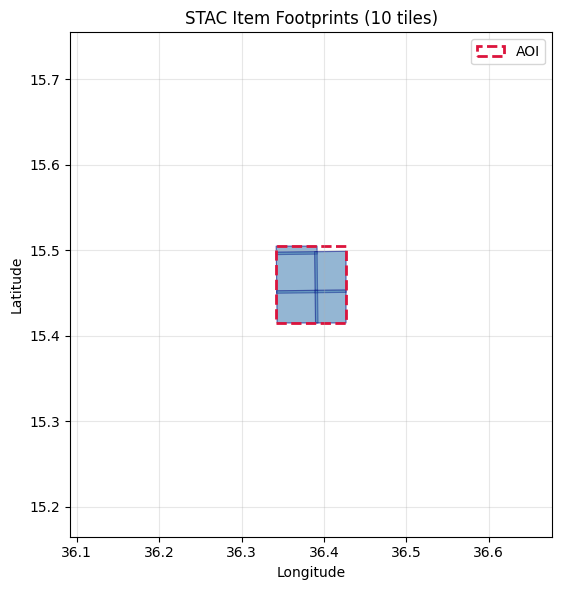

In [14]:
summarise_items(items_gdf)

##### Housekeeping 

In some stac items, there is a mismatch between CRS so we can make sure that we keep the items with mode (most frequent CRS).

In [15]:
# Count occurrences of each CRS type
# This returns a Series where index is the CRS and value is the count
crs_counts = items_gdf['crs'].value_counts()
logger.info(f"CRS Counts:\n{crs_counts}", )

# if more than one crs is found in the items we filter on the most frequent value
if len(crs_counts) > 1:
    # Identify the most frequent CRS
    most_frequent_crs = crs_counts.idxmax()    
    # Filter the GeoDataFrame to keep only that type
    items_gdf = items_gdf[items_gdf['crs'] == most_frequent_crs].copy()

    logger.info(f"Kept rows with CRS: {most_frequent_crs}. {len(items_gdf)}")

04:41:33 [INFO] maxar_pipeline — CRS Counts:
crs
EPSG:32637    10
Name: count, dtype: int64


#### Load Pre/Post Imagery in separate dfs

Maxar dataset contains both before(pre) and after(post) flood imagery. Based on the flood date defined manually we divide the imagery into subsets.

In [16]:
post_df = items_gdf.loc[items_gdf['datetime'] >= FLOOD_DATE]
logger.info(f"{len(post_df)}")

04:41:33 [INFO] maxar_pipeline — 5


We will focus on the post flood images and take the first X (defined in MAX_TILES) to process to speed up and create the MVP based on indices. 

In [17]:
# Keep only a maximum number of tiles
if len(post_df) > MAX_TILES:
    post_df = post_df[:MAX_TILES]
# Reload items from the gdf, incase we have modified the gdf with our criteria
post_items = post_df["_item"].tolist()

logger.info(f"STAC Items of interest for analysis:\n{post_items}")

04:41:33 [INFO] maxar_pipeline — STAC Items of interest for analysis:
[<Item id=37/033131202111/104001007BB6D600>, <Item id=37/033131202113/104001007BB6D600>]


In [18]:
# Similarly for before flood items
pre_df = items_gdf.loc[items_gdf['datetime'] < FLOOD_DATE]
if len(pre_df) > MAX_TILES:
    pre_df = pre_df[:MAX_TILES]
pre_items = pre_df["_item"].tolist()

logger.info(f"{len(pre_items)}")

04:41:33 [INFO] maxar_pipeline — 2


#### Patch Maxar Items
Before we can't pass this data to odc-stac load, we need to manually fix the items dict as the eo:bands are in a nested structure. We first reassign it to the item properties and then define its keys correctly to be able to use odc.stac.load().

In [19]:
MS_BANDS = [band['name'] for band in post_items[0].assets[MS_ASSET_KEY].to_dict()['eo:bands']]
logger.info(MS_BANDS)

# Known band counts for each Maxar asset type
ASSET_BAND_COUNTS = {
    "ms_analytic":  len(MS_BANDS),   # 4-band or 8-band multispectral, take dynamically
    "pan_analytic": 1,   # panchromatic
    "visual":       3,   # RGB preview (B, G, R order)
}

04:41:33 [INFO] maxar_pipeline — ['BAND_C', 'BAND_B', 'BAND_G', 'BAND_Y', 'BAND_R', 'BAND_RE', 'BAND_N', 'BAND_N2']


In [20]:
# Patch items of interest
post_items = [patch_maxar_item(item) for item in post_items]

##### Quick Sanity Check

In [21]:
from odc.stac._mdtools import extract_collection_metadata

# Verify all three assets now have correct band counts
parsed = extract_collection_metadata(post_items[0])
logger.info(f"Band keys: {list(parsed.bands.keys())}")
# Expected: [('ms_analytic', 1..4/8), ('pan_analytic', 1), ('visual', 1..3)]

logger.info(f"BAND_G resolves to: {parsed.aliases.get("BAND_G")}")

assert parsed.aliases.get("BAND_G") == list([('visual', 2), ('ms_analytic', 3)]), (
    f"{MS_ASSET_KEY} band not parsed correctly, Expected: [('visual', 2), ('ms_analytic', 3)] values for BAND_G."
)

04:41:33 [INFO] maxar_pipeline — Band keys: [('ms_analytic', 1), ('ms_analytic', 2), ('ms_analytic', 3), ('ms_analytic', 4), ('ms_analytic', 5), ('ms_analytic', 6), ('ms_analytic', 7), ('ms_analytic', 8), ('pan_analytic', 1), ('visual', 1), ('visual', 2), ('visual', 3)]
04:41:33 [INFO] maxar_pipeline — BAND_G resolves to: [('visual', 2), ('ms_analytic', 3)]


### Distributed Processing & Mosaic Construction

Maxar delivers imagery as individual **tiles**. Our AOI spans multiple tiles, so we must stitch them together into a single seamless **mosaic** before computing indices.

##### Why Dask?

A single Maxar 8-band tile at full resolution can be **4–8 GB** of data. Loading 10 tiles sequentially into RAM would require 40–80 GB. Instead, we use **Dask** to load imagery **lazily** i.e. the actual pixel data is only read when we explicitly call `.compute()`. Until then, Dask builds a task graph describing *what to do*, not *doing it*.

##### Chunk Strategy

Setting `chunks={'x': 2048, 'y': 2048}` divides each tile into 2048×2048 pixel blocks. Each block is processed independently by a Dask worker. Smaller chunks = more parallelism but more overhead; larger chunks = fewer tasks but higher memory per worker. **2048 is a good default** for most AOI sizes.

##### Start Dask Client
This step improves load speed significantly. Morevoer, you can tune LocalCluster and tune it further based on your computer specs.

You don’t have to use Dask, as you can load data directly into memory of the notebook but with huge datasets this takes forever.

In [22]:
# Dask CLuster Initialization
from dask.distributed import Client, LocalCluster

# More optimized cluster based on computer specs but a default one works fine as well
cluster = LocalCluster(n_workers=8, threads_per_worker=2, memory_limit='6GB')
client = Client(cluster)

# Configure rasterio for odc
configure_rio(cloud_defaults=True, client=client, **GDAL_ENV)

# Display dashboard url and cluster specification
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 16,Total memory: 44.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:50458,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:50491,Total threads: 2
Dashboard: http://127.0.0.1:50496/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:50461,


In [23]:
# Some parameters to guide chunks and resolution
CHUNK = 2048
# Flood analysis can be conducted on lower resolution images as well so depending on working memory
# we can define a shrink factor and apply resolution accordingly
resolution = post_items[0].properties['gsd']
SHRINK = 4

# Running with less than 4Gb RAM
if client.cluster.workers[0].memory_manager.memory_limit < dask.utils.parse_bytes("4G"):
    SHRINK = 8
    
if SHRINK > 1:
    resolution = resolution * SHRINK

##### Border Areas

`stac_load` by default loads all available pixels in the requested projection and resolution. When you pass multiple STAC items (tiles), it creates an output grid covering the union bounding box of all tile footprints. Any pixel in that union not covered by a specific tile gets filled with nodata=NaN. That's why we can get white border areas, we can tackle this by constraining to intersection (area of interest + tiles) using **bbox** or **geopolygon**.

04:41:37 [INFO] maxar_pipeline — (36.34579368054551, 15.450064335339608, 36.392220594947645, 15.504883)


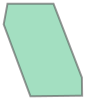

In [24]:
from functools import reduce

# Intersect all tile geometries only where ALL tiles have data
post_union = reduce(lambda a, b: a.union(b), post_df.geometry)
intersection = aoi_geom.intersection(post_union) 

logger.info(intersection.bounds)  # (minx, miny, maxx, maxy) in WGS84
intersection  

In [25]:
%%time

post_ds = stac_load(
    post_items,
    bands=["BAND_B", "BAND_G", "BAND_R", "BAND_N"],
    crs=f"{post_items[0].properties['proj:code']}",
    resolution=resolution,
    chunks={"x": CHUNK, "y": CHUNK},
    dtype="float32",
    nodata=np.nan,
    groupby="solar_day",   # groups tiles from same day into one time slice, okay for maxar
    # bbox=intersection.bounds,
    geopolygon=intersection,
)

logger.info(f"Bands: {','.join(list(post_ds.data_vars))}")
display(post_ds)

04:41:37 [INFO] maxar_pipeline — Bands: BAND_B,BAND_G,BAND_R,BAND_N


<xarray.Dataset> Size: 96MB
Dimensions:      (y: 2718, x: 2201, time: 1)
Coordinates:
  * y            (y) float64 22kB 1.716e+06 1.716e+06 ... 1.71e+06 1.71e+06
  * x            (x) float64 18kB 2.152e+05 2.152e+05 ... 2.202e+05 2.202e+05
  * time         (time) datetime64[ns] 8B 2022-09-02T08:36:22
    spatial_ref  int32 4B 32637
Data variables:
    BAND_B       (time, y, x) float32 24MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    BAND_G       (time, y, x) float32 24MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    BAND_R       (time, y, x) float32 24MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    BAND_N       (time, y, x) float32 24MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>

CPU times: total: 46.9 ms
Wall time: 50.3 ms


In [ ]:
# All downstream band math, index computation, and classification
# will read from worker memory rather than re-fetching remote tiles.
post_ds = client.persist(post_ds)
wait(post_ds)  # block until all tiles are loaded

logger.info("post_ds persisted in worker memory")

In [ ]:
# XArray only contains one time as we group by solar day (usually maxar data is one day)
# we select the first one for our scene/analysis
scene = post_ds.isel(time=0)
scene

#### Scale to reflectance (0-1) before computing indices

The index formulas assume reflectance (0-1) whereas Maxar bands are in raw digital numbers (0-X) not surface reflectance. Consequently, Range of values differ in each Band:

```
NIR range: 635.0, 10000.0 
Red range: 0.0, 255.0
Green range: 3.0, 255.0
Blue range: 0.0, 255.0
```

NDVI with such values saturates to ~1.0 everywhere because NIR >> Red in raw data. This produces impossible scenario in index mapping. We need to scale them accordingly:

- NIR is scaled reflectance (0-10000)
- RBG bands are 8-bit DN (0-255)


In [ ]:
def to_float(xx):
    """Converts to float and maps no data values correctly"""
    _xx = xx.astype("float32")
    nodata = _xx.attrs.pop("nodata", None)
    if nodata is None:
        return _xx
    return _xx.where(xx != nodata)

def to_reflectance(da, scale):
    """Normalise a band to reflectance [0, 1] using its specific scale factor."""
    return (da * scale).clip(0.0, 1.0).astype("float32")

In [ ]:
# NIR delivered as reflectance × 10000
nir   = to_reflectance(to_float(scene.BAND_N), 1 / 10000)

# RGB delivered as 8-bit DN
red   = to_reflectance(to_float(scene.BAND_R), 1 / 255)
green = to_reflectance(to_float(scene.BAND_G), 1 / 255)
blue  = to_reflectance(to_float(scene.BAND_B), 1 / 255)

### Calculate Spectral Indices and Classify Flood 

Spectral indices are **simple band maths formulas** that amplify specific surface properties. They are dimensionless ratios that normalise for illumination differences, making comparisons consistent across different acquisitions. In our case these we will water and vegetation.

We compute four indices:

##### NDWI — Normalised Difference Water Index
$$NDWI = \frac{Green - NIR}{Green + NIR}$$
**Range:** −1 to +1. Positive values (approaching +1) indicate open water. Vegetation and soil are typically negative. This is our primary water detector.

##### NDVI — Normalised Difference Vegetation Index
$$NDVI = \frac{NIR - Red}{NIR + Red}$$
**Range:** −1 to +1. Dense healthy vegetation produces values > 0.3. We use NDVI to distinguish between **open floodwater** and **flooded cropland** (vegetation still present but inundated).

##### FMI — Flood Mud Index
$$FMI = \frac{Red - Blue}{Red + Blue}$$
Designed for **turbid or sediment-laden floodwater** common in Sudanese river systems. Muddy water has higher Red reflectance than Blue, giving a positive FMI. This index helps catch shallow, silty floods that NDWI misses.

##### WRI — Water Ratio Index
$$WRI = \frac{Green + Red}{NIR}$$
Values > 1.0 are generally associated with water presence. Provides a third, independent vote on water probability.

In [ ]:
INDEX_CFG = {
    "NDVI":  dict(cmap="RdYlGn",   vmin=-1,   vmax=1,   label="NDVI"),
    "NDWI":  dict(cmap="RdBu",     vmin=-1,   vmax=1,   label="NDWI"),
    "WRI":   dict(cmap="coolwarm_r",vmin=0,   vmax=3,   label="WRI"),
    "FMI":   dict(cmap="PuBu",     vmin=-1,   vmax=1,   label="FMI"),
    "AWEI":  dict(cmap="Blues",    vmin=-0.5, vmax=0.5, label="AWEI"),
}

In [ ]:
# NDVI — Normalized Difference Vegetation Index
# Range: [-1, 1] | High values = dense vegetation
ndvi = (nir - red) / (nir + red + 1e-8)
ndvi = ndvi.rename("NDVI")

# NDWI — Normalized Difference Water Index (McFeeters 1996)
# Range: [-1, 1] | Positive values = open water surface, uses Green + NIR (SWIR not available)
ndwi = (green - nir) / (green + nir + 1e-8)
ndwi = ndwi.rename("NDWI")

# WRI — Water Ratio Index
# Range: [0, +inf] | Values > 1 strongly indicate water
wri = (green + red) / (nir + blue)
wri = wri.rename("WRI")

# FMI — Flood Mapping Index (optical proxy, no SAR)
# Combines water signal (NDWI) with suppression of vegetation (NDVI)
# Higher FMI = higher flood probability 
fmi = ndwi - ndvi
fmi = fmi.rename("FMI")

# AWEI — Automated Water Extraction Index (no SWIR)
# Designed specifically to suppress built-up and shadow false positives
awei = (blue + 2.5 * green - 1.5 * (nir + red) - 0.25 * blue)
awei = awei.rename("AWEI")

##### Multi-Index Voting System

Using a single index as a binary mask is error-prone:
- NDWI alone can misclassify **urban shadows** as water
- FMI alone can misclassify **red clay soils** as muddy water
- WRI alone can produce noise in agricultural areas

By treating each index as an independent **binary vote** and requiring at least 2 out of 3 votes to agree, we significantly reduce false positives.

##### Output Classes

| Class ID | Label | Detection Rule |
|----------|-------|----------------|
| 0 | No Data | NaN / masked pixels |
| 1 | Undefined | Confidence < 2 AND NDVI ≤ ndvi_threshold |
| 2 | Vegetation | Confidence < 2 AND NDVI > ndvi_threshold |
| 3 | Flood / Open Water | Confidence ≥ 2 |

##### Helper functions to Classify and Plot (maps, indices and floods)

In [ ]:
# Source of truth for all class and index configuration
CLASS_CONFIG = {
    0: {"label": "No Data", "color": "#808080", "is_nodata": True },
    1: {"label": "Undefined", "color": "#d4b483", "is_nodata": False},
    2: {"label": "Vegetation", "color": "#4dac26", "is_nodata": False},
    3: {"label": "Flood / Open Water", "color": "#2166ac", "is_nodata": False},
}

# Precompute colormap array for classify_flood output — used by colorize()
_CLASS_COLORS_RGBA = mcolors.ListedColormap(
    [CLASS_CONFIG[c]["color"] for c in sorted(CLASS_CONFIG)]
).colors  # shape (n_classes, 4) float RGBA


def robust_stretch(data, out_range=(0, 1)):
    """Percentile stretch to [0,1] using 2nd–98th percentile."""
    p2, p98 = np.nanpercentile(data, (2, 98))
    return np.clip((data - p2) / (p98 - p2 + 1e-9), *out_range)


def colorize(xx, colormap):
    """Map integer class array to RGBA using a lookup table."""
    return xr.DataArray(colormap[xx.data], coords=xx.coords, dims=(*xx.dims, "band"))


def classify_flood(
    ndwi, ndvi, wri, fmi, awei,
    ndwi_threshold = 0.3,
    ndvi_threshold = 0.4,   # pixels with NDVI > this are vegetation
    wri_threshold  = 1.2,
    fmi_threshold  = 0.05,
    awei_threshold = 0.0,
    vote_threshold = 2,     # 1=sensitive, 2=balanced, 3=conservative
):
    """Multi-index voting classifier — returns lazy uint8 DataArray with 4 land cover classes."""

    # Per-index water conditions
    votes = sum([
        (ndwi > ndwi_threshold).astype("uint8"),
        (ndvi < ndvi_threshold).astype("uint8"),   # low NDVI = not vegetation = possible water
        (wri  > wri_threshold) .astype("uint8"),
        (fmi  > fmi_threshold) .astype("uint8"),
        (awei > awei_threshold).astype("uint8"),
    ])

    # flag pixel if ANY index is NaN
    any_nan = ndwi.isnull() | ndvi.isnull() | wri.isnull() | fmi.isnull() | awei.isnull()

    flood_class = xr.where(any_nan,               0,  # No Data
                  xr.where(votes >= vote_threshold, 3,  # Flood / Open Water
                  xr.where(ndvi  > ndvi_threshold,  2,  # Vegetation
                                                     1   # Undefined
                  ))).astype("uint8")

    flood_class = flood_class.rename("flood_classification")
    flood_class.attrs.update({
        "long_name":      "Flood and Land Cover Classification",
        "flag_values":    [0, 1, 2, 3],
        "flag_meanings":  "nodata undefined vegetation flood_open_water",
        "nodata":         0,
        **{f"{k}_threshold": v for k, v in dict(
            ndwi=ndwi_threshold, ndvi=ndvi_threshold, wri=wri_threshold,
            fmi=fmi_threshold, awei=awei_threshold, vote=vote_threshold,
        ).items()},
    })
    return flood_class


def plot_flood_analysis(scene, indices, flood_classification):
    """Four-panel flood analysis: RGB / NDWI / NDVI / classification."""

    # Build cmap and norm from CLASS_CONFIG
    class_ids  = sorted(CLASS_CONFIG)
    flood_cmap = mcolors.ListedColormap([CLASS_CONFIG[c]["color"] for c in class_ids])
    flood_norm = mcolors.BoundaryNorm(
        [c - 0.5 for c in class_ids] + [class_ids[-1] + 0.5], flood_cmap.N
    )

    fig, axes = plt.subplots(1, 4, figsize=(26, 7))
    fig.patch.set_facecolor("#f5f5f5")

    # Panel 1 — True colour
    rgb = robust_stretch(np.stack(
        [scene.BAND_R.values, scene.BAND_G.values, scene.BAND_B.values], axis=-1
    ).astype(np.float32))
    axes[0].imshow(rgb)
    axes[0].set_title("True Colour\nRGB Composite", fontsize=12, fontweight="bold", pad=10)
    axes[0].axis("off")

    # Panels 2 & 3 — Spectral indices
    for ax, key, cmap_key in zip(axes[1:3], ["NDWI", "NDVI"], ["NDWI", "NDVI"]):
        cfg  = INDEX_CFG[cmap_key]
        plot = ax.imshow(indices[key].values, cmap=cfg["cmap"], vmin=cfg["vmin"], vmax=cfg["vmax"])
        ax.set_title(f"{cfg['label']}", fontsize=12, fontweight="bold", pad=10)
        ax.axis("off")
        plt.colorbar(plot, ax=ax, fraction=0.046, pad=0.04, label="Index Value")

    # Panel 4 — Classification using colorize()
    # colorize maps integer classes → RGBA directly, avoiding manual norm/cmap
    rgba = colorize(flood_classification, _CLASS_COLORS_RGBA)
    axes[3].imshow(rgba.values)
    axes[3].set_title("Flood Classification\nMulti-Index Voting", fontsize=12, fontweight="bold", pad=10)
    axes[3].axis("off")
    axes[3].legend(
        handles=[mpatches.Patch(color=CLASS_CONFIG[c]["color"], label=CLASS_CONFIG[c]["label"])
                 for c in class_ids],
        loc="lower right", fontsize=9, framealpha=0.85, edgecolor="grey"
    )

    # Statistics
    arr       = flood_classification.values
    valid_px  = np.sum(arr != 0)
    counts    = {c: int(np.sum(arr == c)) for c in class_ids}
    flood_pct = counts[3] / valid_px * 100 if valid_px > 0 else 0

    fig.suptitle(
        f"Flood Analysis\n"
        f"Flood: {counts[3]:,} px ({flood_pct:.1f}%)  |  "
        f"Vegetation: {counts[2]:,} px  |  "
        f"Undefined: {counts[1]:,} px  |  "
        f"No Data: {counts[0]:,} px",
        fontsize=13, fontweight="bold", y=1.03
    )
    plt.tight_layout()
    plt.savefig(outputs_dir / "flood_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    logger.info(f"Flood: {counts[3]:,} px ({flood_pct:.1f}%) | Veg: {counts[2]:,} | "
                f"Undefined: {counts[1]:,} | NoData: {counts[0]:,}")


def get_flood_stats(flood_classification, flood_class=3, min_area_m2=100.0):
    """Vectorise flood pixels and return a GeoDataFrame with spatial statistics."""

    if hasattr(flood_classification.data, "compute"):
        flood_classification = flood_classification.compute()

    crs = flood_classification.rio.crs
    if crs is None:
        raise ValueError("No CRS found — assign with .rio.write_crs() first.")

    transform  = flood_classification.rio.transform()
    arr        = flood_classification.values.astype(np.uint8)
    nodata_ids = [c for c, m in CLASS_CONFIG.items() if m["is_nodata"]]
    valid_mask = ~np.isin(arr, nodata_ids)
    class_mask = (arr == flood_class).astype(np.uint8)

    records = [
        {"geometry": shape(geom), "value": int(val)}
        for geom, val in shapes(class_mask, mask=class_mask, transform=transform)
    ]

    if not records:
        logger.warning(f"No pixels for class {flood_class} ({CLASS_CONFIG[flood_class]['label']})")
        return gpd.GeoDataFrame(columns=["geometry", "area_m2", "area_km2"], crs=str(crs)), {}

    gdf = gpd.GeoDataFrame(records, crs=str(crs))
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
    gdf_utm["area_m2"]  = gdf_utm.geometry.area
    gdf_utm["area_km2"] = gdf_utm["area_m2"] / 1e6

    n_before = len(gdf_utm)
    gdf_utm  = gdf_utm[gdf_utm["area_m2"] >= min_area_m2].reset_index(drop=True)
    logger.info(f"Removed {n_before - len(gdf_utm)} polygons < {min_area_m2} m²")

    total_valid_px = int(valid_mask.sum())
    class_counts   = {CLASS_CONFIG[c]["label"]: int(np.sum(arr == c))
                      for c in CLASS_CONFIG if not CLASS_CONFIG[c]["is_nodata"]}
    class_pct      = {lbl: round(n / total_valid_px * 100, 2) if total_valid_px else 0
                      for lbl, n in class_counts.items()}

    stats = {
        "total_valid_pixels":   total_valid_px,
        "nodata_pixels":        int(np.isin(arr, nodata_ids).sum()),
        "pixel_resolution_m":   round(abs(transform.a), 2),
        "pixel_area_m2":        round(abs(transform.a * transform.e), 2),
        "utm_crs":              str(gdf_utm.crs),
        "class_pixel_counts":   class_counts,
        "class_coverage_pct":   class_pct,
        "flood_class_id":       flood_class,
        "flood_class_label":    CLASS_CONFIG[flood_class]["label"],
        "flooded_pixels":       int(class_mask.sum()),
        "flood_coverage_pct":   round(int(class_mask.sum()) / total_valid_px * 100, 2) if total_valid_px else 0,
        "total_flood_area_km2": round(gdf_utm["area_km2"].sum(), 4),
        "n_flood_polygons":     len(gdf_utm),
        "largest_patch_km2":    round(gdf_utm["area_km2"].max(), 4) if len(gdf_utm) else 0,
        "mean_patch_km2":       round(gdf_utm["area_km2"].mean(), 4) if len(gdf_utm) else 0,
    }

    logger.info("Scene — " + " | ".join(f"{l}: {p}%" for l, p in class_pct.items()))
    logger.info(f"Flood — {stats['flooded_pixels']:,} px / {stats['total_flood_area_km2']} km² "
                f"| {len(gdf_utm):,} polygons | largest: {stats['largest_patch_km2']} km²")

    return gdf_utm, stats

In [ ]:
# Build flood mask lazily
flood = classify_flood(ndwi, ndvi, wri, fmi, awei, )

In [ ]:
# Write indices stack
indices_stack = xr.Dataset({"NDVI": ndvi, "NDWI": ndwi, "WRI": wri,
                             "FMI": fmi,  "AWEI": awei})

In [ ]:
%%time

# dask.compute() merges all three graphs, finds shared subgraphs (band reads, index math) 
computed_scene, computed_indices, computed_flood = dask.compute(
    scene,
    indices_stack,
    flood,
)

logger.info("Computed scene, indices and flood classification.")

In [ ]:
# Define rows and cols based on indices
ncols = 3
nrows = int(np.ceil(len(indices) / ncols))

# Plot
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 6 * nrows),
    constrained_layout=True
)
# Iterate over axes and display each index
axes = axes.flat
for ax, name in zip(axes, indices):
    cfg  = INDEX_CFG[name]
    data = computed_indices[name].squeeze()   # drop time if present

    img = data.plot.imshow(
        ax            = ax,
        cmap          = cfg["cmap"],
        vmin          = min(cfg["vmin"], data.min().values),
        vmax          = max(cfg["vmax"], data.max().values),
        interpolation = "bilinear",            # bilinear >> bicubic for geo data (no ringing)
        add_colorbar  = True,
        add_labels    = True,
        cbar_kwargs   = dict(label=cfg["label"], shrink=0.8, pad=0.02),
    )

    ax.set_title(name, fontsize=15, fontweight="bold", pad=8)
    ax.set_xlabel("X (m)", fontsize=9)
    ax.set_ylabel("Y (m)", fontsize=9)
    ax.tick_params(labelsize=8)

# Hide any unused axes (if n < nrows*ncols)
for ax in axes[len(indices):]:
    ax.set_visible(False)

fig.suptitle("Spectral Indices — Post Flood", fontsize=18, fontweight="bold", y=1.05)
plt.show()

#### The Turbid Water Problem

Standard water indices are built on a spectral assumption that water absorbs strongly in NIR (and SWIR) while reflecting in visible blue/green. Turbid, sediment-laden floodwater violates this assumption because:

1. **Suspended sediment increases reflectance** across all visible bands, especially red and near-infrared, making the water spectrally resemble bare soil or dry land.

2. **NDWI (Green - NIR) / (Green + NIR):** Sediment raises NIR reflectance, driving the index negative — the same signature as dry vegetation or soil.

3. **AWEI and WRI**: Similarly depend on SWIR and NIR suppression, both of which sediment counteracts.

4. **This is not a threshold problem**: Simply lowering the classification threshold will not fix this. The spectral signature is fundamentally misclassified at the sensor level.

This is a well-documented limitation in post-monsoon and riverine flood events in South Asia, the Indus, Ganges, Amazon, and similar systems where peak discharge coincides with peak sediment transport.

### Post-Processing: Vectorization & Reporting

We convert our raster flood map into **vector polygons** using `rasterio.features.shapes`. This is the standard raster-to-vector workflow in GIS. A GIS specialist needs numbers, not just pictures. Here we convert the "Water" pixels into Polygons and calculate the total flooded area in square kilometers.

- Raster results are pixel-based -> they can't easily answer questions like *"how many individual flood patches are there?"* or *"what is the perimeter-to-area ratio?"*
- Vector polygons are the standard format for GIS workflows in QGIS, ArcGIS, and spatial databases
- Area statistics require projection to a metric CRS (like UTM) — which is straightforward with GeoPandas but cumbersome with raw arrays


In [ ]:
# Simutaneously Plot the classified scene, NDWI index and flood mask from the previous step
plot_flood_analysis(
    scene=computed_scene,
    indices=computed_indices,
    flood_classification=computed_flood,
)

In [ ]:
if computed_flood.rio.crs is None:
    # Assign CRS from our scene object via rio
    computed_flood = computed_flood.rio.write_crs(computed_scene.rio.crs, inplace=True)
    computed_flood = computed_flood.rio.write_transform(inplace=True)

In [ ]:
# Display stats for flooded area
flood_gdf, stats = get_flood_stats(
    flood_classification=computed_flood, # Flood mask from last step
)

logger.info(f"Number of Flood Polygons: {len(flood_gdf)}")
logger.info(f"Classification stats:\n{stats}")

### What the Results Are Telling Us

The flood analysis output reveals a critical limitation in the current approach:

- **True Colour (RGB):** The imagery clearly shows a river carrying high sediment load,
  producing characteristic brown/turbid water rather than the clear blue typically
  associated with water.

- **NDWI Map:** The index is almost entirely red (negative values), meaning it is
  detecting *no water* across the scene. This is a false negative caused by the
  brownish spectral signature of turbid water. NDWI relies on high Green and low
  NIR reflectance, which breaks down when sediment dominates.

- **Flood Classification:** The result shows predominantly "Not Flooded"  pixels,
  with zero flooded pixels detected (0.0% of valid area). The NoData region likely
  corresponds to cloud cover or missing data in the upper portion of the scene.

**Bottom line:** Standard water indices are built on a spectral assumption: water absorbs strongly in
NIR and SWIR while reflecting in visible blue/green. Turbid, sediment-laden floodwater
violates this assumption because sediment raises NIR reflectance, driving the index negative, 
same as dry vegetation or soil. Our indices (NDWI, NDVI, AWEI, WRI, FMI) have
fundamentally failed here. Not due to implementation error, but because the physics
of turbid water violates their core assumptions. Simply lowering the classification threshold
will not fix this. The spectral signature is fundamentally misclassified at the
sensor level. This is a well-documented limitation in post-monsoon and riverine flood events in
South Asia, the Indus, Ganges, Amazon, and similar systems where peak discharge
coincides with peak sediment transport.

**Recommendation and Next Steps** are provided at the end of the notebook.

## Save COGs to Cloud (S3)

Push the built mosaic and computed flood masks to cloud storage as Cloud Optimized GeoTIFFs (COGs). We use s3fs to define the S3 connection using AWS credentials loaded from environment variables, and odc.geo for efficient dask-native COG writing.

#### Initialise S3 Connection

We use s3fs to create a filesystem-like interface to S3. Credentials are pulled from environment variables — never hardcoded.

In [ ]:
import s3fs

# Authenticate using environment variables (set via .env or your cloud environment)
fs = s3fs.S3FileSystem(
    key=os.getenv('AWS_ACCESS_KEY_ID'),
    secret=os.getenv('AWS_SECRET_ACCESS_KEY')
)

#### Define Output Paths

Construct the full S3 destination paths for both the mosaic and flood mask outputs. Assuming the **Naming Convention** provided corresponds to these S3 files (Was not completely sure of this).

In [ ]:
# Load S3 bucket config from environment
s3_bucket = os.getenv('AWS_BUCKET_NAME')
s3_key    = os.getenv('AWS_BUCKET_PATH')
s3_dst    = f"s3://{s3_bucket}/{s3_key}"

# Full S3 output paths for mosaic and flood mask COGs
mosaic_path = f"{s3_dst}/Test_TL_MFarjadMalik_Sudan_22August2022_mosaic.tif"
mask_path   = f"{s3_dst}/Test_TL_MFarjadMalik_Sudan_22August2022_mask.tif"

logger.info(f"{mosaic_path=}")
logger.info(f"{mask_path=}")

#### Prepare Mosaic for Export

Convert the xarray Dataset (multi-variable) to a DataArray by stacking bands into a single band dimension required by more writers including save_cog_with_dask.

In [ ]:
scene

In [ ]:
# Convert XArray Dataset to DataArray by stacking bands into a 'band' dimension
scene_da = scene.to_array(dim="band")  # shape: (band, y, x)

# Cast to uint16 and fill NaN nodata with 0 before writing
scene_da = assign_crs(computed_scene_da, crs=computed_scene_da.rio.crs)
scene_da_int = scene_da.fillna(0).astype("uint16")

#### Write Mosaic COG to S3

We use save_cog_with_dask from odc.geo which writes directly to S3 in a fully lazy, dask-native way (no local temp files needed). DEFLATE compression with predictor=2 is well suited for integer/uint16 imagery.

In [ ]:
%%time
from odc.geo.cog import save_cog_with_dask
from odc.geo.xr import assign_crs

# Write mosaic as COG directly to S3
result = save_cog_with_dask(
    computed_scene_da_int,
    dst=mosaic_path,
    compression="DEFLATE",      # lossless, good compression ratio
    predictor=2,                # horizontal differencing (best for continuous imagery)
    level=6,                    # compression level (1=fast, 9=smallest)
    blocksize=512,              # tile size in pixels (512x512 is COG standard)
    overview_resampling="average",  # average resampling for overviews (smooth for imagery)
)

# Trigger dask computation to upload
result.compute()

#### Write Flood Mask COG to S3

The flood mask is a categorical uint8 array, so we use nearest resampling for overviews to preserve hard class boundaries.

In [ ]:
flood

In [ ]:
%%time

# Flood DataArray is already format {y, x} and datatype uint8
# Rechunk flood before saving to distribute evenly across workers
flood = flood.chunk({"y": 1024, "x": 1024}) 
# Although correct crs is not assigned for geobox crs used by dask
flood = assign_crs(flood, crs=scene_da_int.rio.crs)

# Write flood mask as COG directly to S3
result = save_cog_with_dask(
    flood,
    dst=mask_path,
    compression="DEFLATE",
    predictor=2,                    # suitable for integer/uint8 data
    level=4,
    blocksize=512,
    overview_resampling="nearest",  # preserves binary mask values
    stats=False,        # removes stats dependency
    # tile_batching=4,  # batch more tiles per S3 part upload
)

# Trigger dask computation to upload
result.compute()

In [ ]:
# # Interrupt kernel first, then abort dangling uploads
# s3.abort_multipart_upload(
#     Bucket=os.getenv("AWS_BUCKET_NAME"),
#     Key=mask_path.replace(f"s3://{os.getenv('AWS_BUCKET_NAME')}/", ""),
#     UploadId="<id_from_earlier>"  # if you have it
# )

#### Verify if the files are pushed correctly

We  don't have list object access on the s3 key so we will use boto client and get metadata for our specific files. 

In [ ]:
# initialize s3 client using AWS credentials
s3 = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)

In [ ]:
# For each of our paths i.e. mosaic and mask (defined earlier)
for path in [mosaic_path, mask_path]:
    
    key = path.replace(f"s3://{s3_bucket}/", "")
    try:
        response = s3.head_object(
            Bucket=s3_bucket,
            Key=key
        )
        size_mb = response["ContentLength"] / 1e6
        logger.info(f" {key}  |  {size_mb:.2f} MB  |  {response['LastModified']}")
    except s3.exceptions.ClientError as e:
        if e.response["Error"]["Code"] == "404":
            logger.error(f"File Not found: {key}")
        elif e.response["Error"]["Code"] == "403":
            logger.warning(f"No read permission: {key}")
        else:
            logger.warning(f"Error: {key} — {e}")

##### Alternative: Upload COGs via Rasterio + Boto3

Rasterio also provides functions to store the file locally first and then transfer to cloud in COG format. This approach is commented out. It writes the file locally first as a raw TIFF, translates it to COG format using cog_translate, then uploads via boto3. While more explicit, it is significantly slower and requires local disk space proportional to the output file size. 

The odc.geo.write_cog approach below writes to a temporary file ssynchronously which is also not desirable.

In [ ]:
# %%time

# from odc.geo.cog import write_cog
# import tempfile, boto3

# # Write locally first, then upload
# with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as f:
#     tmp_path = f.name

# write_cog(computed_flood, tmp_path, overwrite=True)  # synchronous, no dask

# # Upload via boto3
# s3.upload_file(tmp_path, s3_bucket, mask_path.replace(f"s3://{os.getenv('AWS_BUCKET_NAME')}/", ""))

In [ ]:
# %%time

# # Config
# TEMP_RAW   = "raw_temp.tif"
# TEMP_COG   = "mosaic_cog.tif"

# # If you have a Dataset, convert to DataArray first
# scene_da = scene.to_array(dim="band")               # (band, y, x)
# mosaic_int = scene_da.fillna(0).astype("uint16")
# mosaic_int.rio.write_nodata(0, inplace=True)

# # Write raw tiled TIFF locally
# logger.info("Writing temp TIFF...")
# mosaic_int.rio.to_raster(
#     TEMP_RAW,
#     tiled=True,
#     windowed=True,      # processes in windows — keeps memory low
#     mem_limit=2000,
#     compress="LZW"
# )

# # Translate to COG 
# logger.info("Translating to COG...")
# config = {
#     "GDAL_TIFF_INTERNAL_MASK": True,
#     "GDAL_NUM_THREADS": "ALL_CPUS"
# }

# cog_translate(
#     TEMP_RAW,
#     TEMP_COG,
#     cog_profiles.get("deflate"),
#     nodata=0,
#     add_mask=True,
#     config=config,
#     in_memory=False,
#     quiet=False       # set True to silence output
# )

# # Upload to S3
# logger.info(f"Uploading to {mosaic_path} ...")
# s3_client = boto3.client(
#         "s3",
#         aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
#         aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
#         # region_name=os.getenv("AWS_REGION_NAME"),
#     )
# s3_client.upload_file(
#     Filename=TEMP_COG,
#     Bucket=os.getenv("AWS_BUCKET_NAME"),
#     Key=mosaic_path.replace(f"s3://{os.getenv('AWS_BUCKET_NAME')}/", ""),
#     Callback=lambda bytes_transferred: logger.info(
#         f"  Transferred: {bytes_transferred / 1e6:.1f} MB", end="\r"
#     )
# )
# logger.info(f"Upload complete {mosaic_path}")

# # Cleanup temp files
# for f in [TEMP_RAW, TEMP_COG]:
#     if os.path.exists(f):
#         os.remove(f)
#         logger.info(f"🗑️  Removed {f}")

### Recommendations & Next Steps

The indices implemented above work well for clear water. For uncharacteristic flood events like these where rivers carry heavy sediment loads (such as the Blue Nile at Kassala), consider the following additions:

### 1. Modified Indices

##### MNDWI — Modified NDWI (Gold Standard for Turbid Water)

$$MNDWI = \frac{Green - SWIR}{Green + SWIR}$$

Water strongly absorbs SWIR (Short-Wave Infrared) energy regardless of suspended sediment. This makes MNDWI far more robust than NDWI for silty/muddy floodwater. Currently this band is not available in maxar.

##### NDWI with NIR2

$$NDWI_NIR2 = \frac{Green - NIR2}{Green + NIR2}$$


NIR2 is more SWIR-like — better water/soil separation in turbid conditions

### 2. Pre/Post Flood Change Detection

Maxar data provides images for pre-flood conditions, which can serve as a baseline for our analysis. We can use pre dataset (already filtered out) to create a second mosaic which captures the normal spectral signature of the landscape e.g. vegetation, bare soil, roads, and any permanent water bodies.

Instead of derived indices, we compute per-band difference and ratio images between before and after mosaics.
- band = post_band - pre_band          # Difference
- band = post_band / pre_band          # Ratio

In [ ]:
# Create a new ds for before pre flood items, we already had them mapped out in the "Search for Data" section
pre_items = [patch_maxar_item(item) for item in pre_items]

In [ ]:
%%time

# Load pre items in data cube
pre_ds = stac_load(
    pre_items,
    bands=["BAND_B", "BAND_G", "BAND_R", "BAND_N"],
    crs=f"{pre_items[0].properties['proj:code']}",
    resolution=resolution,
    chunks={"x": CHUNK, "y": CHUNK},
    dtype="float32",
    nodata=np.nan,
    groupby="solar_day",
    geopolygon=intersection,
    # fail_on_error=False,
)

logger.info(f"Bands: {','.join(list(pre_ds.data_vars))}")
display(pre_ds)

In [ ]:
# All downstream band math, index computation, and classification
# will read from worker memory rather than re-fetching remote tiles.
pre_ds = client.persist(pre_ds)
wait(pre_ds)  # block until all tiles are loaded

logger.info("pre_ds persisted in worker memory")

In [ ]:
computed_pre_ds = pre_ds.squeeze("time", drop=True).astype("float32").compute()

In [ ]:
from scipy import ndimage

def compute_flood_mask(pre_ds, post_ds,
                       mag_threshold=None,
                       percentile=10,
                       texture_window=5,
                       min_patch_pixels=100
                      ):
    """
    CVA-based flood mask from pre/post computed xarray Datasets.
    """

    def to_ref(ds):
        return xr.Dataset({
            "BAND_B": (ds.BAND_B / 255.0).clip(0, 1).fillna(0).astype("float32"),
            "BAND_G": (ds.BAND_G / 255.0).clip(0, 1).fillna(0).astype("float32"),
            "BAND_R": (ds.BAND_R / 255.0).clip(0, 1).fillna(0).astype("float32"),
            "BAND_N": (ds.BAND_N / 10000.0).clip(0, 1).fillna(0).astype("float32"),
        }, coords=ds.coords)

    pre  = to_ref(pre_ds)
    post = to_ref(post_ds)

    # Per-band difference
    diff = xr.Dataset({
        "dB": post.BAND_B - pre.BAND_B,
        "dG": post.BAND_G - pre.BAND_G,
        "dR": post.BAND_R - pre.BAND_R,
        "dN": post.BAND_N - pre.BAND_N,
    })

    magnitude = np.sqrt(diff.dN**2 + diff.dR**2 + diff.dG**2 + diff.dB**2)
    flood_direction = diff.dN < 0

    # Local std texture using scipy directly on numpy arrays
    def local_std(arr, window):
        mean    = ndimage.uniform_filter(arr,    size=window)
        mean_sq = ndimage.uniform_filter(arr**2, size=window)
        return np.sqrt(np.maximum(mean_sq - mean**2, 0))

    tex_pre   = local_std(pre.BAND_N.values,  texture_window)
    tex_post  = local_std(post.BAND_N.values, texture_window)
    d_texture = xr.DataArray(tex_pre - tex_post, dims=["y", "x"], coords={"y": pre.y, "x": pre.x})

    def norm(da):
        mn, mx = float(np.nanmin(da.values)), float(np.nanmax(da.values))
        return (da - mn) / (mx - mn + 1e-9)

    score = (0.45 * norm(magnitude)
           + 0.35 * norm(-diff.dN)
           + 0.20 * norm(d_texture))

    # Threshold on flood_direction pixels only — avoids 0-inflation
    score_np   = score.values
    dir_np     = flood_direction.values
    flood_vals = score_np[dir_np & ~np.isnan(score_np)]

    if mag_threshold is None:
        mag_threshold = float(np.percentile(flood_vals, percentile)) if flood_vals.size > 0 else 0.0
        logger.info(f"mag_threshold [{percentile}th pct] = {mag_threshold:.4f}")

    flood_raw = (score < mag_threshold) & flood_direction

    # Morphological cleanup
    flood_np            = flood_raw.values.astype(bool)
    labeled, n_features = ndimage.label(flood_np)
    if n_features > 0:
        sizes                     = ndimage.sum(flood_np, labeled, range(1, n_features + 1))
        remove_mask               = small[labeled - 1] if (small := np.array(sizes) < min_patch_pixels).any() else None
        if remove_mask is not None:
            remove_mask[labeled == 0] = False
            flood_np[remove_mask]     = False

    coords     = {"y": pre.y, "x": pre.x}
    flood_mask = xr.DataArray(
        flood_np.astype(np.uint8), dims=["y", "x"], coords=coords, name="flood_mask"
    )
    diagnostics = xr.Dataset({
        "cva_magnitude":  magnitude,
        "nir_change":     diff.dN,
        "texture_change": d_texture,
        "flood_score":    score,
        "flood_mask":     flood_mask,
    }, coords=coords)

    logger.info(f"Flood pixels: {int(flood_np.sum()):,} / {flood_np.size:,} "
                f"({flood_np.sum() / flood_np.size * 100:.2f}%)")

    return flood_mask, diagnostics

In [ ]:
%%time

flood_mask, diag = compute_flood_mask(computed_pre_ds, computed_scene)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

plot_cfg = [
    (diag.nir_change, "RdBu", True, "Change in NIR"),
    (diag.cva_magnitude, "hot_r", True, "CVA Magnitude"),
    (diag.flood_score, "YlOrRd", True, "Flood Score"),
    (diag.flood_mask, "Blues", True, "Flood Mask"),
]

for ax, (data, cmap, robust, title) in zip(axes, plot_cfg):
    data.plot.imshow(
        ax           = ax,
        cmap         = cmap,
        robust       = robust,
        interpolation= "bilinear",
        add_labels   = True,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.savefig(outputs_dir / "pre_post_flood_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"Flooded area: {int(flood_mask.sum()):,} pixels")

##### Update the mask on S3 as this is best suited

In [ ]:
flood_mask

In [ ]:
if flood_mask.rio.crs is None:
    # Assign CRS from our scene object via rio
    flood_mask = flood_mask.rio.write_crs(computed_scene.rio.crs, inplace=True)
    flood_mask = flood_mask.rio.write_transform(inplace=True)

In [ ]:
%%time

# Flood DataArray is already format {y, x} and datatype uint8
# Rechunk back to dask for save_cog_with_dask
flood_mask = flood_mask.chunk({"y": 1024, "x": 1024})  # ✅ converts back to dask

# Although correct crs is not assigned for geobox crs used by dask
flood_mask = assign_crs(flood_mask, crs=scene_da_int.rio.crs)

# Write flood mask as COG directly to S3
result = save_cog_with_dask(
    flood_mask,
    dst=mask_path,
    compression="DEFLATE",
    predictor=2,                    # suitable for integer/uint8 data
    level=4,
    blocksize=512,
    overview_resampling="nearest",  # preserves binary mask values
    stats=False,        # removes stats dependency
    # tile_batching=4,  # batch more tiles per S3 part upload
)

# Trigger dask computation to upload
result.compute()

#### Post-Processing & Refinement

Flooded pixels show consistent change, some tuning can be done to extract areas with higher changes making it viable for flood mapping e.g. Stronger river flows as seen in the plots above. Further post-processing steps are needed to get real value from these mosaics. Some of them in no order could be:

- Minimum mapping unit: Discard patches below a size threshold (e.g., <100 m²) to reduce false positives (is being done but can be tuned)
- Permanent water mask: Subtract pre-existing water bodies (using hydro datasets)
- DEM constraint: Mask pixels above a certain elevation

### 2. Sentinel-1 SAR Integration

Synthetic Aperture Radar (SAR) is the most robust solution for turbid flood mapping (and flood mapping in general) because it does not rely on water colour or optical reflectance. SAR detects the *dielectric properties* and *surface roughness* of the scene:

- **Floodwater** acts as a specular reflector, returning very low backscatter (dark in SAR imagery) regardless of sediment content or turbidity.
- **Dry land and vegetation** scatter radar energy back strongly (bright in SAR).

#### Recommended Dataset
- **Sensor:** Sentinel-1 GRD (Ground Range Detected)
- **Polarisation:** VV + VH dual-pol (VH is particularly sensitive to inundation
  under vegetation canopy)
- **Resolution:** 10m (IW swath mode)
- **Source:** ESA Copernicus Open Access Hub / Google Earth Engine

#### Flood Detection Approach with SAR
- Compute the **log-ratio** between pre- and post-event backscatter.
- Pixels with a significant *decrease* in backscatter (~3–5 dB threshold) indicate inundation onset.
- Apply Otsu thresholding or a supervised classifier on the change image.
- This approach is immune to turbidity and works under cloud cover.

### Cleanup

Properly close the Dask cluster to release workers and free memory. Always run this cell when you've finished the analysis.

In [ ]:
# shutdown dask cluster
client.close()
cluster.close()

logger.info("Shut down successful.")

In [ ]:
# Release Python objects
import gc

# Force garbage collection
gc.collect()

## Summary for the Team

The flood detection results are not a failure of the pipeline. It is a diagnostic signal that the spectral index approach is inappropriate for this scene or atleast in the bands provided. Having more bands (SWIR) might help the cause. 

Turbid, sediment-laden floodwater is one of the most challenging targets in optical Earth Observation. Unlike clear or vegetated floodwater which absorbs NIR and appears dark; high sediment loads increase water-leaving radiance across visible and NIR wavelengths, causing floodwater to appear spectrally similar to bare soil or dry land. This is well documented in literature on similar semi-arid river flood events (e.g. Nile basin, Sahel). 

Moreover, SWIR bands are absent in the current dataset. SWIR (1.6µm, 2.2µm) is the most diagnostic spectral region for water detection under turbid conditions, as liquid water strongly absorbs SWIR regardless of sediment load. Without it, indices like NDWI and MNDWI (the industry standard for flood mapping) cannot be computed.

Despite its limitations as a flood delineation product, the optical analysis retains scientific value:

Land cover context: Characterising urban extent, vegetation density, and bare soil fraction around the affected area — useful for exposure and vulnerability assessment.
Change detection baseline: The CVA magnitude and NIR difference layers produced in this notebook remain valid inputs for a multi-source change analysis.
Scene quality assessment: Confirming image quality, cloud cover, and acquisition suitability for downstream image fusion and analysis.


##### Recommended Path Forward

The path to a reliable flood extent map can be improved using:

1. SAR — Sentinel-1 GRD (Priority)
Synthetic Aperture Radar is the operational standard for flood mapping under these conditions. C-band backscatter from Sentinel-1 is insensitive to sediment load, works through cloud cover, and has been operationally validated for flood mapping by Copernicus EMS, UNOSAT, and JRC. Open access archive available via Copernicus Dataspace.
2. SWIR-Capable Optical (Sentinel-2 or Landsat-8/9)
If optical is required, Sentinel-2 MSI provides SWIR bands at 20m resolution. MNDWI (Green−SWIR / Green+SWIR) significantly outperforms NDWI for turbid water and is the recommended index for this scene type.
3. Pre/Post Change Detection (Already Partially Implemented)
The change detection framework in this notebook is architecturally sound. With a SAR or SWIR-capable pre-event baseline, the CVA and composite score approach can be directly re-applied with meaningful results.